# Differentiable Ray Tracing from First Principles

We build a ~100 line pure Python example inspired by Peter Shirley's *Ray Tracing in One Weekend*.
The goal is to expose how differential rendering works: we render a simple sphere and backpropagate
image-space error to a scene parameter (the sphere's horizontal position) without using any deep-learning framework.

## Learning Goals
- Review the classic pinhole-camera ray tracing pipeline.
- Implement Lambertian shading for a single sphere.
- Differentiate the rendered image with respect to the sphere center via finite differences.
- Use the gradient to iteratively correct the scene, mirroring neural network training.

## Camera, Rays, and Shading Building Blocks
We start by defining small data classes for rays and the camera plus helper utilities for intersection and shading.
Everything stays close to Shirley's text, with carefully commented code to aid graduate-level self-study.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams["figure.dpi"] = 120

In [7]:
@dataclass
class Ray:
    origin: np.ndarray
    direction: np.ndarray

def unit_vector(v: np.ndarray) -> np.ndarray:
    return v / np.linalg.norm(v)

@dataclass
class Camera:
    width: int
    height: int
    origin: np.ndarray
    lower_left_corner: np.ndarray
    horizontal: np.ndarray
    vertical: np.ndarray

def make_camera(width: int = 128, height: int = 128) -> Camera:
    aspect = width / height
    viewport_height = 2.0
    viewport_width = aspect * viewport_height
    focal_length = 1.0
    origin = np.array([0.0, 0.0, -1.0])
    horizontal = np.array([viewport_width, 0.0, 0.0])
    vertical = np.array([0.0, viewport_height, 0.0])
    lower_left_corner = origin + np.array([
        -viewport_width / 2,
        -viewport_height / 2,
        focal_length,
    ])
    return Camera(width, height, origin, lower_left_corner, horizontal, vertical)

def hit_sphere(center: np.ndarray, radius: float, ray: Ray) -> float:
    oc = ray.origin - center
    a = np.dot(ray.direction, ray.direction)
    b = 2.0 * np.dot(oc, ray.direction)
    c = np.dot(oc, oc) - radius ** 2
    discriminant = b ** 2 - 4 * a * c
    if discriminant < 0:
        return -1.0
    sq = np.sqrt(discriminant)
    t = (-b - sq) / (2 * a)
    if t > 0:
        return t
    t = (-b + sq) / (2 * a)
    return t if t > 0 else -1.0

def shade(ray: Ray, center: np.ndarray, radius: float, light_dir: np.ndarray) -> np.ndarray:
    t = hit_sphere(center, radius, ray)
    if t < 0:
        unit_dir = unit_vector(ray.direction)
        blend = 0.5 * (unit_dir[1] + 1.0)
        return (1.0 - blend) * np.array([1.0, 1.0, 1.0]) + blend * np.array([0.5, 0.7, 1.0])
    hit_point = ray.origin + t * ray.direction
    normal = unit_vector(hit_point - center)
    intensity = max(np.dot(normal, light_dir), 0.0)
    base = np.array([0.8, 0.2, 0.2])
    ambient = 0.1
    return np.clip((ambient + 0.9 * intensity) * base, 0.0, 1.0)

## Rendering Function and Loss Definition
The renderer casts one primary ray per pixel, applies Lambertian shading, and returns an RGB image.
We also set up a mean-squared-error (MSE) loss and a finite-difference gradient utility that emulate
the backward pass of differentiable renderers such as PyTorch3D.

In [8]:
def render_image(center_x: float, camera: Camera, radius: float = 0.5) -> np.ndarray:
    image = np.zeros((camera.height, camera.width, 3), dtype=np.float32)
    sphere_center = np.array([center_x, 0.0, 0.5])
    light_dir = unit_vector(np.array([0.3, 0.5, -1.0]))
    for j in range(camera.height):
        v = (j + 0.5) / camera.height
        for i in range(camera.width):
            u = (i + 0.5) / camera.width
            direction = (
                camera.lower_left_corner
                + u * camera.horizontal
                + v * camera.vertical
                - camera.origin
            )
            ray = Ray(camera.origin, unit_vector(direction))
            image[camera.height - j - 1, i] = shade(ray, sphere_center, radius, light_dir)
    return image

def mse(image: np.ndarray, target: np.ndarray) -> float:
    return 0.5 * np.mean((image - target) ** 2)

def finite_difference_grad(center_x: float, camera: Camera, target: np.ndarray, eps: float = 1e-3) -> float:
    loss_plus = mse(render_image(center_x + eps, camera), target)
    loss_minus = mse(render_image(center_x - eps, camera), target)
    return (loss_plus - loss_minus) / (2 * eps)

## Differentiable Rendering Demo
We now create a "ground-truth" image with a sphere centered at $x=0.2$ and try to recover that
parameter starting from a poor guess. The only optimization signal comes from image-space MSE and
a finite-difference gradient, mimicking how neural renderers tune scene parameters.

In [9]:
camera = make_camera(128, 128)
true_center = 0.2
target_image = render_image(true_center, camera)

estimate = -0.25
initial_image = render_image(estimate, camera)

loss_history = []
center_history = []
grad_history = []
learning_rate = 0.6
iterations = 20

for _ in range(iterations):
    current_image = render_image(estimate, camera)
    loss = mse(current_image, target_image)
    grad = finite_difference_grad(estimate, camera, target_image)
    loss_history.append(loss)
    center_history.append(estimate)
    grad_history.append(grad)
    estimate -= learning_rate * grad

final_image = render_image(estimate, camera)
print(f"Recovered center ≈ {estimate:.3f} (target {true_center})")

Recovered center ≈ 0.243 (target 0.2)


### Visualizing the Optimization
The target image (left) is the observation we want to match. The initial guess (middle) clearly
misplaces the sphere. After gradient descent (right) the renderer aligns with the target. The loss
plot shows how differentiable rendering drives the scene parameter towards the optimum.

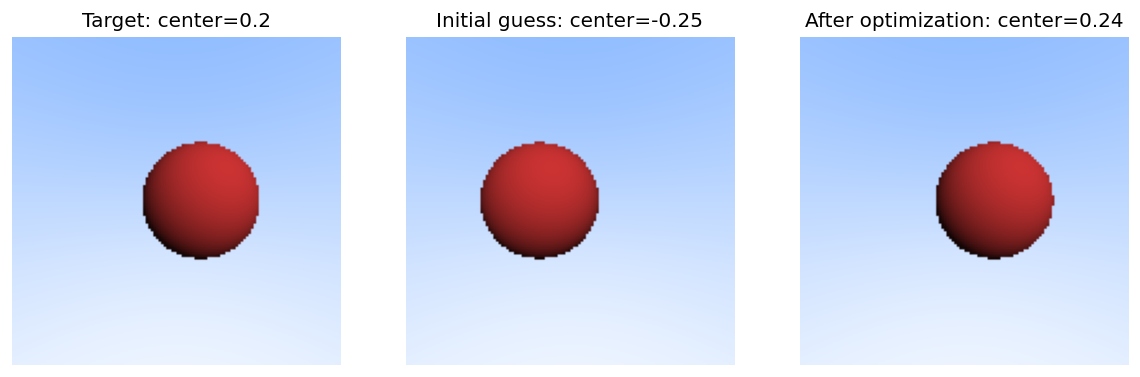

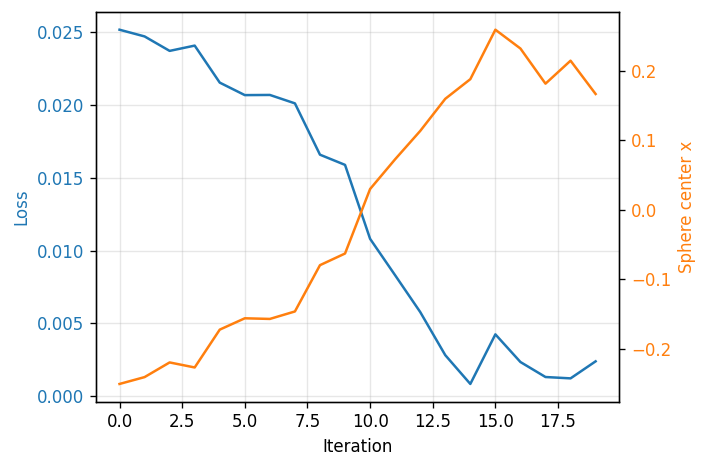

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image)
axes[0].set_title("Target: center=0.2")
axes[1].imshow(initial_image)
axes[1].set_title("Initial guess: center=-0.25")
axes[2].imshow(final_image)
axes[2].set_title(f"After optimization: center={estimate:.2f}")
for ax in axes:
    ax.axis("off")
plt.show()

fig, ax1 = plt.subplots(figsize=(6, 4))
steps = np.arange(len(loss_history))
ax1.plot(steps, loss_history, label="MSE loss", color="tab:blue")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(steps, center_history, label="Estimated center", color="tab:orange")
ax2.set_ylabel("Sphere center x", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Takeaways and Next Steps
- Finite-difference gradients already let us update geometry parameters from image error, embodying the core idea of differentiable rendering.
- Replacing the scalar parameter with vectors (vertices, materials) and swapping finite differences for analytic or auto-diff gradients leads directly to modern neural renderers such as PyTorch3D.
- You can extend this notebook by optimizing lighting, fitting multiple pixels with stochastic sampling, or embedding the renderer inside a neural network for inverse rendering tasks.